# Introduction

This report aims to analyze the Coursera dataset to gain a comprehensive understanding of various course characteristics, student enrollment trends, and rating dynamics within the online learning platform. The dataset provides information on a multitude of online courses, including details such as course titles, organizations, certificate types, ratings, difficulty levels, and student enrollment figures.

Throughout this analysis, we will:
- Examine the distribution of course difficulty and certificate types  
- Identify top-performing courses and organizations based on enrollment and ratings  
- Explore relationships between course ratings, enrollment numbers, and difficulty levels  

These insights will help in understanding the landscape of online education on Coursera and highlight factors that contribute to course popularity and perceived quality.

---

## About Coursera

### Coursera Inc.

Coursera Inc. is a U.S.-based massive open online course (MOOC) provider founded in 2012 by Stanford University computer science professors Andrew Ng and Daphne Koller. The platform partners with universities, companies, and organizations worldwide to deliver online courses, professional certificates, and degree programs across a wide range of disciplines.

#### Key Information (Latest Available Data)

- **Stock ticker:** COUR (NYSE)  
- **Founded:** 2012  
- **Headquarters:** California, United States  
- **Founders:** Andrew Ng, Daphne Koller  

#### Business & Platform

- Offers courses, certifications, and full degrees in areas such as:
  - Technology  
  - Business  
  - Data science  
  - Artificial intelligence  
- Partners with hundreds of universities and organizations globally  
- Focuses on upskilling and reskilling individuals and enterprises  

#### Latest Metrics (2025–2026)

- **Registered learners:** ~140–190 million globally  
- **Employees:** ~1,300 (2025)  
- **Annual revenue (2025):** ~$757 million  
- **Courses available:** 7,000+  

#### Overview

Coursera has evolved into one of the leading global online learning platforms, serving millions of learners and institutions. Its offerings span academic education, professional development, and industry-recognized credentials, and are available in multiple languages.

---

# Dataset Exploration & Exploratory Data Analysis (EDA)

## Data Brief

The dataset used in this analysis was scraped from the Coursera platform. It contains information about various online courses offered by different organizations.

- **Total entries:** 890 courses  
- **Total features:** 6 key attributes  

---

## Dataset Features

### `course_title`
- Represents the title of the course  
- Provides an overview of the subject or topic covered  

### `course_organization`
- Indicates the organization or institution offering the course  
- Examples include universities, companies, or training providers  

### `course_certificate_type`
- Describes the type of certification provided upon completion  
- Examples:
  - Professional Certificate  
  - Specialization  
  - Course Certificate  

### `course_rating`
- Represents the average rating of the course  
- Based on learner reviews and feedback  

### `course_difficulty`
- Indicates the difficulty level of the course  
- Common levels:
  - Beginner  
  - Intermediate  
  - Advanced  

### `course_students_enrolled`
- Shows the total number of learners enrolled  
- Reflects course popularity and reach  

---

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of examining and understanding a dataset through initial investigation. It helps to:

- Uncover patterns  
- Detect anomalies  
- Test hypotheses  
- Validate assumptions  

EDA typically involves the use of **summary statistics** and **visualization techniques** before applying formal modeling or machine learning algorithms.

---

## Objectives of EDA

- Identify patterns and trends in the data  
- Detect outliers or anomalies  
- Understand variable distributions  
- Test initial hypotheses  
- Check data quality and assumptions  

---

## Methods Used

EDA is commonly performed using:

- **Descriptive statistics**
  - Mean  
  - Median  
  - Standard deviation  

- **Data visualization**
  - Histograms  
  - Bar charts  
  - Box plots  
  - Scatter plots  

- **Correlation analysis**  

- **Data cleaning and preprocessing checks**  

# Data Loading and Initial Cleaning

### Required Modules:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps
import os
import seaborn as sns
from scipy import stats
import warnings

In [2]:
df = pd.read_csv("coursea_data.csv")
df

,Unnamed: 0,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
0,134,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,743,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,874,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
3,413,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
4,635,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k
...,...,...,...,...,...,...,...
886,236,Программирование на Python,Mail.Ru Group,SPECIALIZATION,4.5,Intermediate,52k
887,883,Психолингвистика (Psycholinguistics),Saint Petersburg State University,COURSE,4.8,Mixed,21k
888,545,Разработка интерфейсов: вёрстка и JavaScript,E-Learning Development Fund,SPECIALIZATION,4.5,Intermediate,30k
889,875,Русский как иностранный,Saint Petersburg State University,SPECIALIZATION,4.6,Intermediate,9.8k


In [3]:
df=df.drop("Unnamed: 0", axis=1) 
df

,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
0,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
3,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
4,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k
...,...,...,...,...,...,...
886,Программирование на Python,Mail.Ru Group,SPECIALIZATION,4.5,Intermediate,52k
887,Психолингвистика (Psycholinguistics),Saint Petersburg State University,COURSE,4.8,Mixed,21k
888,Разработка интерфейсов: вёрстка и JavaScript,E-Learning Development Fund,SPECIALIZATION,4.5,Intermediate,30k
889,Русский как иностранный,Saint Petersburg State University,SPECIALIZATION,4.6,Intermediate,9.8k


In [4]:
df['course_students_enrolled'] = df['course_students_enrolled'].str.replace('k', '*1000', regex=False)
df['course_students_enrolled'] = df['course_students_enrolled'].str.replace('m', '*1000000', regex=False)
df['course_students_enrolled'] = df['course_students_enrolled'].str.replace(',', '', regex=False)
df['course_students_enrolled'] = df['course_students_enrolled'].apply(lambda x: eval(x) if isinstance(x, str) else x)
df['course_students_enrolled'] = pd.to_numeric(df['course_students_enrolled'], errors='coerce')

print("Info after converting 'course_students_enrolled' column:")
df.info()
print("\nFirst 5 rows with updated 'course_students_enrolled' column:")
display(df.head())

Info after converting 'course_students_enrolled' column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   course_title              891 non-null    object 
 1   course_organization       891 non-null    object 
 2   course_Certificate_type   891 non-null    object 
 3   course_rating             891 non-null    float64
 4   course_difficulty         891 non-null    object 
 5   course_students_enrolled  891 non-null    float64
dtypes: float64(2), object(4)
memory usage: 41.9+ KB

First 5 rows with updated 'course_students_enrolled' column:


,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
0,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5300.0
1,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17000.0
2,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130000.0
3,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91000.0
4,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320000.0


In [5]:
df.describe(include=['object']).T

,count,unique,top,freq
course_title,891,888,Developing Your Musicianship,2
course_organization,891,154,University of Pennsylvania,59
course_Certificate_type,891,3,COURSE,582
course_difficulty,891,4,Beginner,487


# Exploratory Data Analysis

## General overview of courses and students:

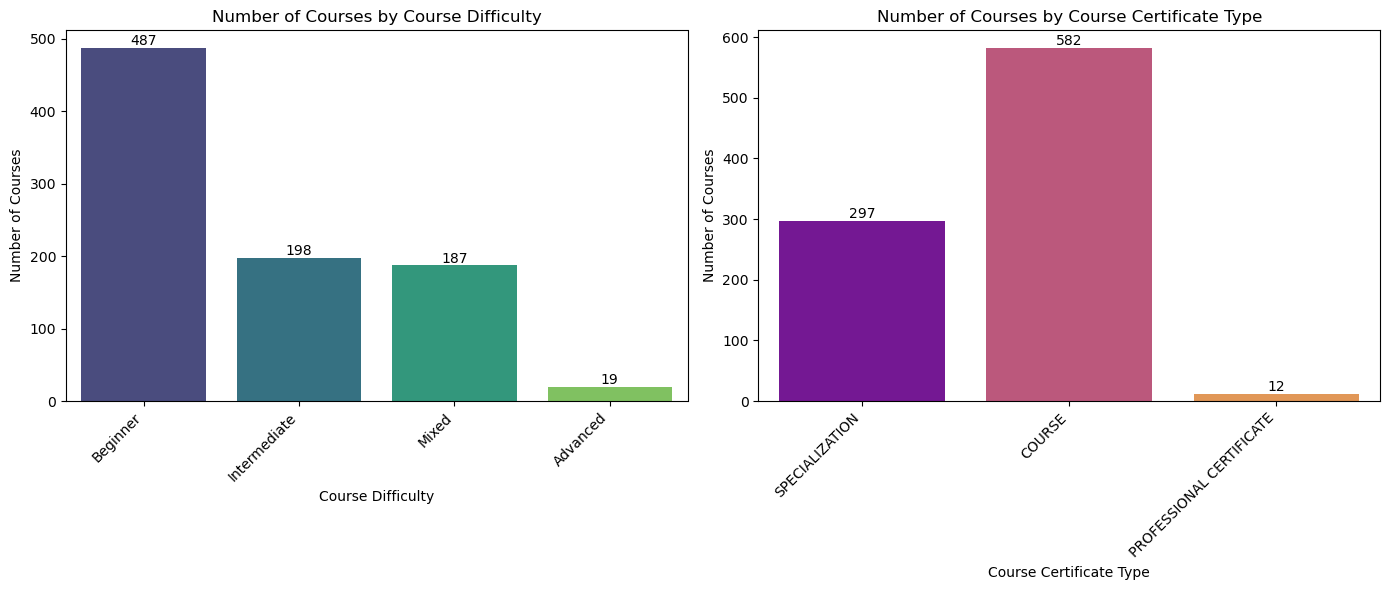

In [6]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
ax1 = sns.countplot(data=df, x='course_difficulty', hue='course_difficulty', palette='viridis', legend=False)
plt.title('Number of Courses by Course Difficulty')
plt.xlabel('Course Difficulty')
plt.ylabel('Number of Courses')
plt.xticks(rotation=45, ha='right')
# Add numbers on top of the bars
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.subplot(1, 2, 2)
ax2 = sns.countplot(data=df, x='course_Certificate_type', hue='course_Certificate_type', palette='plasma', legend=False)
plt.title('Number of Courses by Course Certificate Type')
plt.xlabel('Course Certificate Type')
plt.ylabel('Number of Courses')
plt.xticks(rotation=45, ha='right')
# Add numbers on top of the bars
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

### 📊 Course Insights

The analysis shows that most courses fall under **Beginner (487)** and **Intermediate (198)** levels, followed by **Mixed (187)** courses, while **Advanced (19)** courses are relatively rare.

This indicates that Coursera primarily focuses on **entry-level and moderately skilled learners**, with limited emphasis on highly advanced or specialized content.

In terms of certification, the platform is dominated by:

- **COURSE:** 582  
- **SPECIALIZATION:** 297  
- **Professional Certificate:** 12  

This highlights Coursera’s strong focus on **short, flexible, and skill-based learning programs**, rather than long-term or highly structured academic pathways.

## Top 10 courses with the highest enrollment:

In [7]:
top_10_courses = df.sort_values(by='course_students_enrolled', ascending=False)
top_10_courses = top_10_courses.head(10)

print("Top 10 Courses by Student Enrollment:")
display(top_10_courses[['course_title', 'course_students_enrolled']])

Top 10 Courses by Student Enrollment:


,course_title,course_students_enrolled
564,Machine Learning,3200000.0
815,The Science of Well-Being,2500000.0
688,Python for Everybody,1500000.0
674,Programming for Everybody (Getting Started wit...,1300000.0
196,Data Science,830000.0
129,Career Success,790000.0
261,English for Career Development,760000.0
765,Successful Negotiation: Essential Strategies a...,750000.0
199,Data Science: Foundations using R,740000.0
211,Deep Learning,690000.0


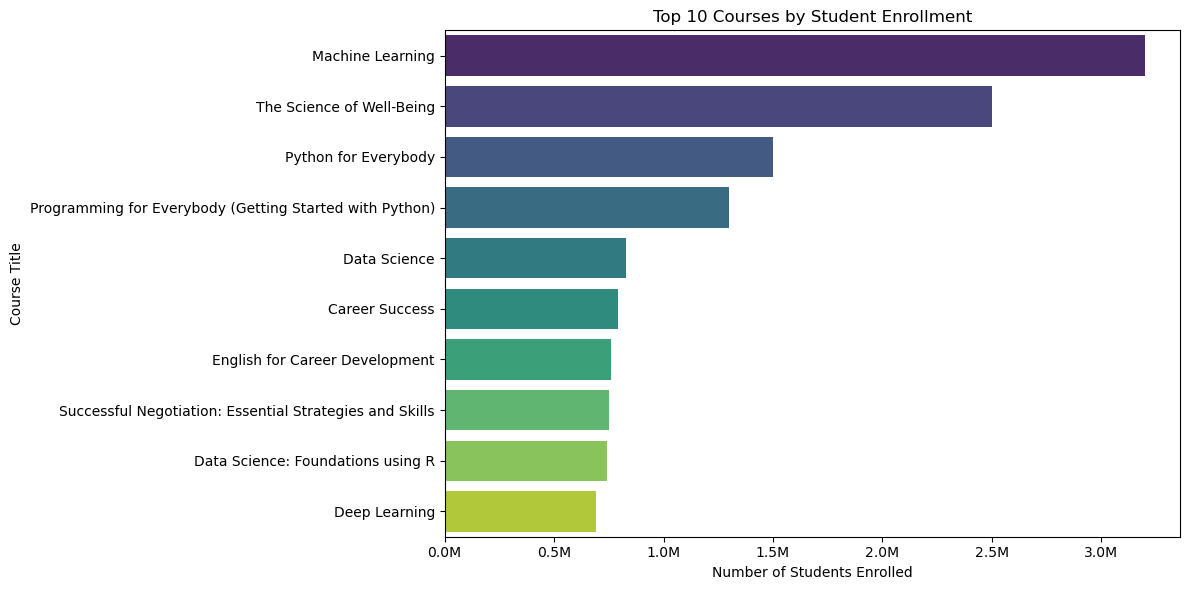

In [8]:
import matplotlib.ticker as mticker

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='course_students_enrolled', y='course_title', data=top_10_courses, hue='course_title', palette='viridis', legend=False)
plt.title('Top 10 Courses by Student Enrollment')
plt.xlabel('Number of Students Enrolled')
plt.ylabel('Course Title')

formatter = mticker.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M')
ax.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

## Top 10 course providers:

In [9]:
organization_enrollment = df.groupby('course_organization')['course_students_enrolled'].sum().reset_index()

top_10_organizations = organization_enrollment.sort_values(by='course_students_enrolled', ascending=False).head(10)

print("Top 10 Course Providers by Student Enrollment:")
display(top_10_organizations)

Top 10 Course Providers by Student Enrollment:


,course_organization,course_students_enrolled
135,University of Michigan,7437700.0
138,University of Pennsylvania,5501300.0
85,Stanford University,4854000.0
123,"University of California, Irvine",4326000.0
48,Johns Hopkins University,4298900.0
20,Duke University,3967600.0
148,Yale University,3952000.0
38,IBM,2956400.0
150,deeplearning.ai,2863400.0
34,Google Cloud,2604300.0


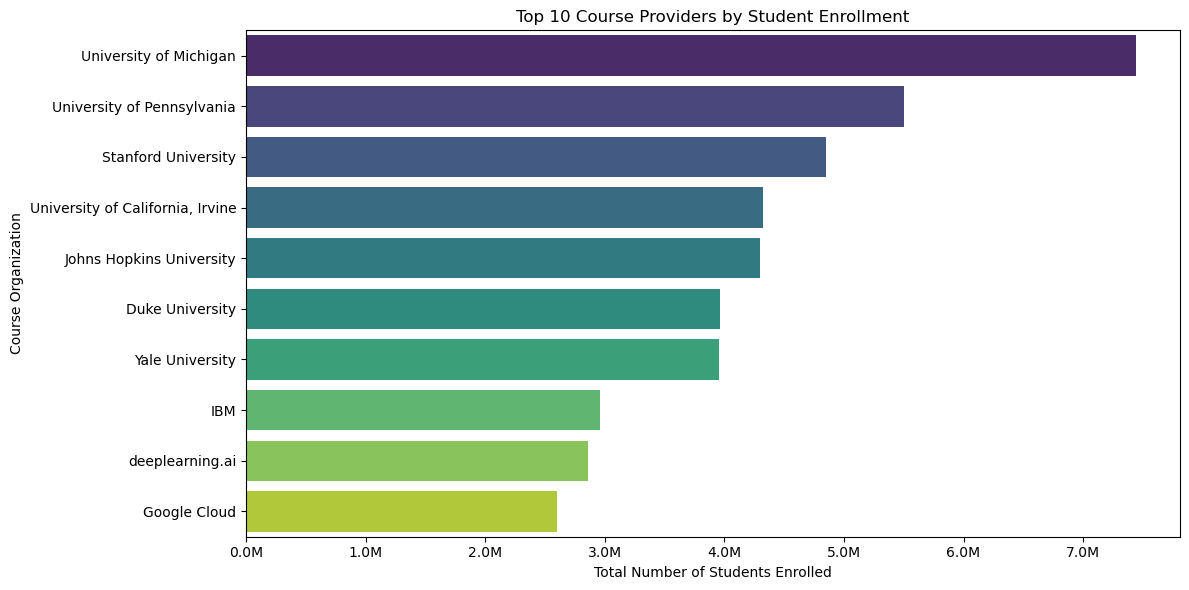

In [10]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='course_students_enrolled', y='course_organization', data=top_10_organizations, hue='course_organization', palette='viridis', legend=False)
plt.title('Top 10 Course Providers by Student Enrollment')
plt.xlabel('Total Number of Students Enrolled')
plt.ylabel('Course Organization')

formatter = mticker.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M')
ax.xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

## Average course rating for the top 5 organizations:

In [11]:
top_5_org_names = top_10_organizations['course_organization'].head(5).tolist()

df_top_5_orgs = df[df['course_organization'].isin(top_5_org_names)]

average_ratings_top_5_orgs = df_top_5_orgs.groupby('course_organization')['course_rating'].mean().reset_index()

average_ratings_top_5_orgs = average_ratings_top_5_orgs.sort_values(by='course_rating', ascending=False)

print("Average Course Rating for Top 5 Organizations by Student Enrollment:")
display(average_ratings_top_5_orgs)

Average Course Rating for Top 5 Organizations by Student Enrollment:


,course_organization,course_rating
1,Stanford University,4.768750
3,University of Michigan,4.729268
4,University of Pennsylvania,4.696610
0,Johns Hopkins University,4.660714
2,"University of California, Irvine",4.596296


## Course Ratings Distributions:

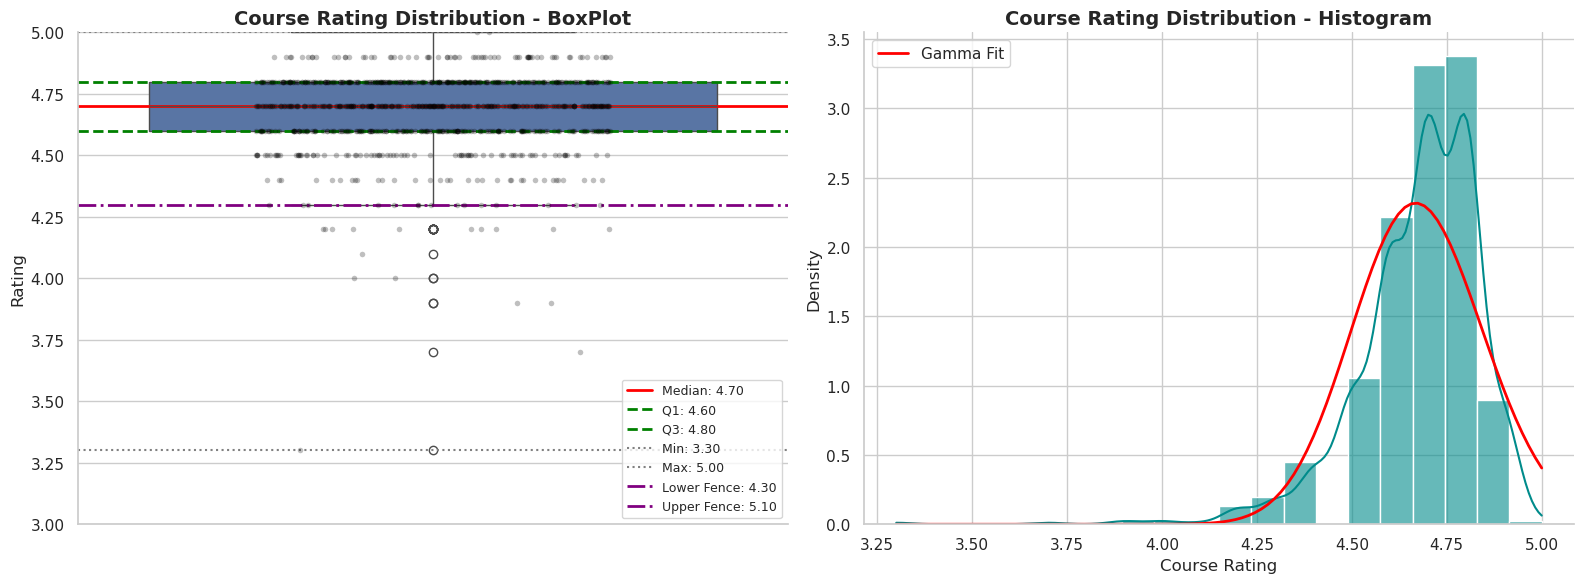

In [12]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]

sns.boxplot(
    y="course_rating",
    data=df,
    color="#4C72B0",
    showfliers=True,
    ax=ax1
)

sns.stripplot(
    y="course_rating",
    data=df,
    color="black",
    alpha=0.25,
    jitter=0.25,
    size=4,
    ax=ax1
)

q1 = df["course_rating"].quantile(0.25)
median = df["course_rating"].median()
q3 = df["course_rating"].quantile(0.75)

iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

min_val = df["course_rating"].min()
max_val = df["course_rating"].max()

ax1.axhline(median, color='red', linestyle='-', linewidth=2, label=f"Median: {median:.2f}")
ax1.axhline(q1, color='green', linestyle='--', linewidth=2, label=f"Q1: {q1:.2f}")
ax1.axhline(q3, color='green', linestyle='--', linewidth=2, label=f"Q3: {q3:.2f}")
ax1.axhline(min_val, color='gray', linestyle=':', linewidth=1.5, label=f"Min: {min_val:.2f}")
ax1.axhline(max_val, color='gray', linestyle=':', linewidth=1.5, label=f"Max: {max_val:.2f}")
ax1.axhline(lower_fence, color='purple', linestyle='-.', linewidth=2, label=f"Lower Fence: {lower_fence:.2f}")
ax1.axhline(upper_fence, color='purple', linestyle='-.', linewidth=2, label=f"Upper Fence: {upper_fence:.2f}")
ax1.legend(loc="lower right", fontsize=9)

ax1.set_title("Course Rating Distribution - BoxPlot", fontsize=14, weight='bold')
ax1.set_ylabel("Rating")
ax1.set_ylim(3, 5)

ax2 = axes[1]

sns.histplot(
    df["course_rating"],
    bins=20,
    kde=True,
    color="darkcyan",
    stat="density",
    edgecolor="white",
    alpha=0.6,
    ax=ax2
)

data = df["course_rating"]
shape, loc, scale = stats.gamma.fit(data)

x = np.linspace(data.min(), data.max(), 100)
y = stats.gamma.pdf(x, shape, loc=loc, scale=scale)

ax2.plot(x, y, color="red", linewidth=2, label="Gamma Fit")

ax2.set_title("Course Rating Distribution - Histogram", fontsize=14, weight='bold')
ax2.set_xlabel("Course Rating")
ax2.set_ylabel("Density")
ax2.legend()

sns.despine()
plt.tight_layout()
plt.show()

**Insights:**
- Ratings are highly concentrated between **4.5 and 4.9**, with a median of **4.7**, indicating consistently high satisfaction.
- The distribution shows **low variability** (IQR = 0.2), meaning most courses receive very similar ratings.
- There is a **slight negative skew**, with a small tail of lower-rated courses.

**Outliers:**
- Courses rated below **4.3** are considered outliers.
- Notable low-end outliers include **3.3, 3.7, and 3.9**.
- There are **no upper outliers**, as the maximum rating (5.0) is within the expected range.

**Interpretation:**
- The dataset reflects a **strong positive bias**, with most courses rated highly.
- Ratings are **compressed near the top**, suggesting a **ceiling effect**.
- Low-rated outliers highlight **potential areas for improvement** and are the most informative points in the dataset.

## Course rating distribution based on the difficulty level:

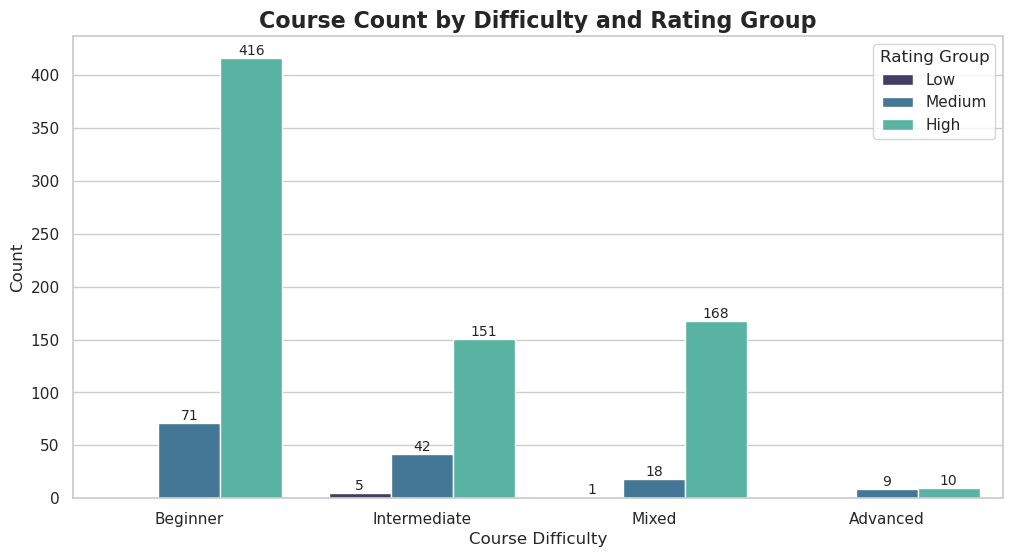

In [13]:
df["rating_group"] = pd.cut(
    df["course_rating"],
    bins=[3, 4, 4.5, 5],
    labels=["Low", "Medium", "High"]
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    x="course_difficulty",
    hue="rating_group",
    data=df,
    palette="mako"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

ax.set_title("Course Count by Difficulty and Rating Group", fontsize=16, weight='bold')
ax.set_xlabel("Course Difficulty")
ax.set_ylabel("Count")

plt.legend(title="Rating Group")
plt.show()

**Key Takeaways**
- **Beginner courses dominate** the platform in both quantity and ratings  
- **High ratings are consistent** across all difficulty levels  
- **Advanced content is limited**, indicating an opportunity for expansion  
- **Low-rated courses are rare**, suggesting high satisfaction but reduced differentiation  

---

**User Experience Effect**

- The presence of a small number of low-rated courses in the intermediate and mixed categories may be influenced by differences in user experience.
- Learners at these levels are typically more experienced, allowing them to evaluate course quality more critically. In contrast, beginners may lack prior benchmarks and therefore tend to rate courses more generously.
- As a result, lower ratings in intermediate and mixed categories may not necessarily indicate poorer course quality, but rather reflect **more critical and informed evaluations** from users.
- This highlights an important consideration: course ratings are influenced not only by content quality, but also by the **expectations and experience level of learners**.

## Course rating distribution based on the course type:

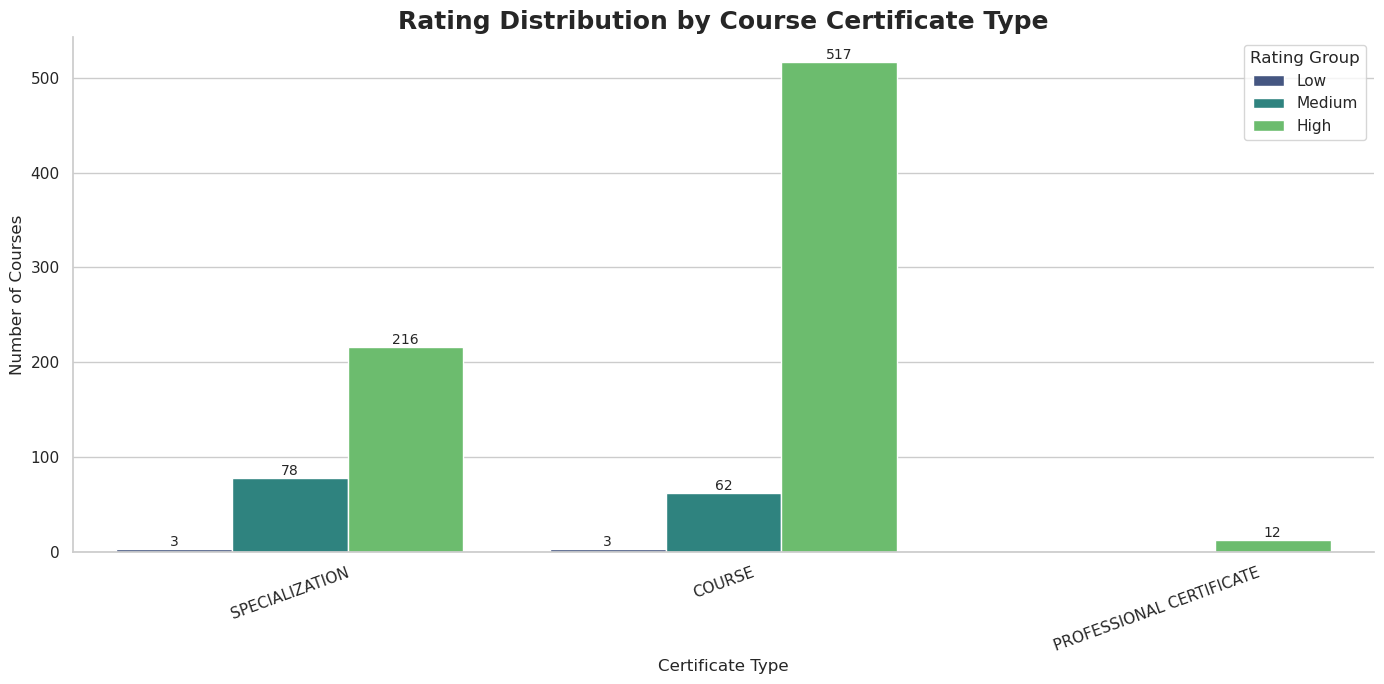

In [14]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 7))

ax = sns.countplot(
    x="course_Certificate_type",
    hue="rating_group",
    data=df,
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10)

ax.set_title("Rating Distribution by Course Certificate Type", fontsize=18, weight='bold')
ax.set_xlabel("Certificate Type", fontsize=12)
ax.set_ylabel("Number of Courses", fontsize=12)

plt.xticks(rotation=20)

plt.legend(title="Rating Group")

sns.despine()
plt.tight_layout()
plt.show()

- The dominance of high ratings across all certificate types suggests a **strong positive bias** or consistently high-quality content.
- The large number of high-rated standard courses indicates that they are the **core offering of the platform**.
- The limited number of professional certificates highlights a **potential opportunity for expansion** in more advanced or career-focused programs.
- Slightly higher medium ratings in specializations may indicate **greater variability in course quality or learner expectations**.

## Correlation analysis to understand how course_rating and course_students_enrolled relate to each other:

Correlation Matrix:


,course_rating,course_students_enrolled
course_rating,1.00000,0.07109
course_students_enrolled,0.07109,1.00000


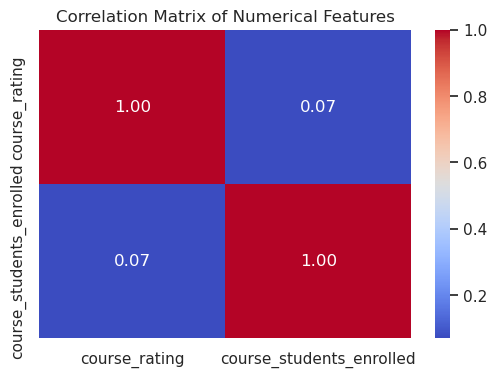

In [15]:
numerical_df = df[['course_rating', 'course_students_enrolled']]

correlation_matrix = numerical_df.corr()

print("Correlation Matrix:")
display(correlation_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

The correlation coefficient between **course_rating** and **course_students_enrolled** is approximately **0.071**, indicating a **very weak positive relationship**. This means that while higher-rated courses may have slightly more enrollments, the effect is **minimal and not statistically significant**. Overall, this suggests that **other factors play a much more important role** in influencing student enrollment than course ratings alone.

# 🔑 Key Insights from Course Analysis

### 🎓 Dominance of Beginner-Level Courses
A large proportion of courses are designed for **beginners**, and these courses attract the highest number of enrollments.

- **Insight:** Beginner-friendly content drives the majority of user engagement  
- **Implication:** Platforms prioritize accessibility to reach a broader audience  

---

### ⭐ Ratings Are Highly Concentrated
Most courses have ratings between **4.5 and 5.0**, with very few low-rated courses.

- **Insight:** Course ratings are consistently high across the platform  
- **Implication:** Ratings alone are not a strong differentiator for course popularity  

---

### 👥 Skewed Enrollment Distribution
Enrollments are unevenly distributed, with a small number of courses receiving extremely high participation while most have relatively low enrollments.

- **Insight:** A few courses dominate in terms of popularity  
- **Implication:** The platform follows a **winner-takes-most** pattern  

---

### 🏫 Influence of Course Providers
Courses offered by well-known institutions tend to have significantly higher enrollments.

- **Insight:** Brand reputation strongly influences learner decisions  
- **Implication:** Learners prefer courses from trusted providers  

---

### ⚖️ Impact of Course Difficulty on Enrollment
A clear trend is observed:
- **Beginner courses** → highest enrollments  
- **Intermediate courses** → moderate enrollments  
- **Advanced courses** → lowest enrollments  

- **Insight:** Enrollment decreases as course difficulty increases  
- **Implication:** Advanced courses cater to a smaller, niche audience  

---

### 🔗 Weak Relationship Between Ratings and Popularity
Highly rated courses do not always correspond to high enrollment numbers.

- **Insight:** Popularity depends on multiple factors beyond ratings  
- **Implication:** Topic relevance, accessibility, and visibility play a larger role  

---

### 📈 Demand for Career-Oriented Topics
Courses in fields such as **Data Science, Business, Programming, and AI** attract the most learners.

- **Insight:** Learners are primarily interested in job-relevant skills  
- **Implication:** Career advancement is a key driver of enrollment  

---

## 🧠 Conclusion

This analysis shows that the platform is largely driven by **accessible, beginner-level content** that appeals to a wide audience. While course ratings remain consistently high, they do not significantly influence enrollment patterns.

Instead, factors such as **course difficulty, provider reputation, and topic relevance** play a more critical role in determining popularity.

Additionally, the distribution of enrollments is highly skewed, with a small number of highly popular courses dominating learner participation. This highlights the importance of **visibility, branding, and subject demand**.

Overall, online learning platforms are most effective when they prioritize:
- Accessibility  
- Credibility  
- Practical, career-oriented content  